# Malata mountain + tau-decay geometry


Visual sanity check for the v6 pipeline after switching the mountain to **`malata.h5`**
and the shower primaries to the real tau events in **`tau_wholesky.h5`**.

Both files live in the **same site-local ENU frame** (`x=East, y=North, z=Up`), with the
origin at the mesh's `location` (lon −71.97°, lat −15.58°). `load_tr_mountain` now reads
that origin from the mesh, so the mountain centroids and the tau decay positions share
`(East, North, Up) = 0`.

This notebook plots:
1. the **mountain** detector region (footprint + height),
2. the **tau decays** overlaid on the mountain,
3. the **initial detector layouts** placed over the mountain,
4. a combined **overlay** of all three.


## 0 - Coordinate systems & transformations

Everything shares one physical frame: site-local **ENU** (East, North, Up), right-handed
(E x N = U), metres, origin at the malata mesh `location` (lon -71.969, lat -15.577). What differs
is how each object is stored or parameterised before it lands in that frame.

| Object | Native form | In the ENU frame |
|---|---|---|
| Mountain (`malata.h5`) | ECEF vertices [m] | rotated to ENU; centroids stored as [North, Up, East] |
| Tau decays (`tau_wholesky.h5`) | ENU (East, North, Up) | position + direction, same origin |
| Detectors | (North, East) horizontal | Up = SurfaceUpMap(North, East) on the terrain |
| Showers | shower-local [x, y, layer, E, t] | transverse (x,y) -> (North, Up); layer -> East depth |

**Transformations**
- **ECEF -> ENU** (mountain): rotate the mesh about the site origin (`load_tr_mountain`).
- **Detector (North, East) -> Up**: bilinear terrain lookup, `Up = SurfaceUpMap(North, East)`.
- **Shower placement** (real tau position, Step 1): translate the cloud so its transverse centroid
  lands at the decay's (North, Up), and shift `layer_index` by `(east_entry - East_decay)/layer_dx`
  so the real East sets which detector plane it aligns with. A point's East = `east_entry - layer*layer_dx`.
- All plots below use right-handed ENU with **x = East, y = North, z = Up**.

The last section demonstrates the shower placement explicitly.

In [1]:
%matplotlib inline
import os, sys
# Runtime only: put the v6 repo dir on sys.path so `import modules_v6` works from
# notebooks/ (modules_v6 in turn injects the v3 + v4 dirs). Editor go-to-definition
# is handled statically by python.analysis.extraPaths in ../.vscode/settings.json.
_V6 = os.path.abspath(".." if os.path.isdir("../modules_v6") else ".")
if _V6 not in sys.path:
    sys.path.insert(0, _V6)

import numpy as np
import torch
import h5py
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

import modules_v6  # noqa: F401 — sys.path injection for v3/v4
from modules_v4.tr_geometry import load_tr_mountain
from modules_v6.tr_surface_map_ne import SurfaceUpMap
from modules_v6.detector_strategies_ne import (
    layout_grid, layout_center_gaussian, layout_uniform_random, layout_latin_hypercube)
from modules_v6.tau_showers import load_tau_primaries
from modules_v6.constants import (
    GEOMETRY_PATH_RESOLVED, GEOMETRY_GROUP, DET_KEY,
    EAST_ENTRY, LAYER_EAST_DX, N_PLANES, N_DETECTORS,
    TAU_WHOLESKY_PATH, LOG_E_MIN, LOG_E_MAX)

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25})
print("mesh :", os.path.basename(GEOMETRY_PATH_RESOLVED), "/", GEOMETRY_GROUP)
print("taus :", os.path.basename(TAU_WHOLESKY_PATH))


mesh : malata.h5 / malata
taus : tau_wholesky_n750k.h5


In [2]:
# ── Mountain (malata) in site-local ENU: centroids columns are (North, Up, East) ──
mtn = load_tr_mountain(GEOMETRY_PATH_RESOLVED, GEOMETRY_GROUP, DET_KEY,
                       east_entry=EAST_ENTRY, layer_east_dx=LAYER_EAST_DX, n_planes=N_PLANES)
mE, mN, mU = mtn.centroids_ENU[:, 0], mtn.centroids_ENU[:, 1], mtn.centroids_ENU[:, 2]
surface = SurfaceUpMap.from_mountain(mtn).to("cpu")    # differentiable Up = g(North, East)
print(f"malata detector region: {len(mN)} triangle centroids")
print(f"  North [{mN.min():7.0f}, {mN.max():7.0f}]  East [{mE.min():7.0f}, {mE.max():7.0f}]  "
      f"Up [{mU.min():.0f}, {mU.max():.0f}] m")

# ── Tau decays (all events) + the in-band subset used for training ──
# The batch job writes a run-tagged corpus (tau_wholesky_<n>_<survivors>.h5), so
# the bare TAU_WHOLESKY_PATH name usually does not exist. constants.py resolves
# this centrally, so Step 0 and this notebook always read the SAME corpus.
print(f"[tau] {os.path.basename(TAU_WHOLESKY_PATH)}")
with h5py.File(TAU_WHOLESKY_PATH, "r") as f:
    tpos = f["position"][...]      # (3, N) rows = East, North, Up
    tEne = f["energy"][...]        # (N,) GeV
tE_e, tN_n, tU_u = tpos[0], tpos[1], tpos[2]
inband = (tEne >= 10**LOG_E_MIN) & (tEne <= 10**LOG_E_MAX)
print(f"tau decays: {tpos.shape[1]} total, {int(inband.sum())} in-band "
      f"[1e{LOG_E_MIN:g}, 1e{LOG_E_MAX:g}] GeV (the primaries Step 0 generates)")

# Decays "near the mountain". tau_wholesky.jl step 5b now applies a --mindist cut
# (default 1 km) so the tau has room to build a shower before the observation mesh.
# A side effect: NO decay lands inside the 1.4 km footprint any more, so the old
# "inside the obs bbox" test selects an empty set and every plot built on it goes
# blank (or NaN). Select on distance to the footprint centre instead.
NEAR_R  = 3000.0                                   # m
_cE, _cN = 0.5 * (mE.min() + mE.max()), 0.5 * (mN.min() + mN.max())
_r_ctr   = np.hypot(tE_e - _cE, tN_n - _cN)
near_mtn = _r_ctr < NEAR_R
print(f"  nearest decay {_r_ctr.min():.0f} m from the footprint centre; "
      f"{int(near_mtn.sum())} within NEAR_R={NEAR_R:.0f} m "
      f"({int((near_mtn & inband).sum())} of them in-band)")

# ── Initial detector layouts on the mountain (a few strategies) ──
rng = np.random.default_rng(0)
layouts = {
    "grid":     layout_grid(mtn, N_DETECTORS, rng=rng),
    "center":   layout_center_gaussian(mtn, N_DETECTORS, sigma=400.0, rng=rng),
    "uniform":  layout_uniform_random(mtn, N_DETECTORS, rng=rng),
    "latin_hc": layout_latin_hypercube(mtn, N_DETECTORS, rng=rng),
}
layouts = {k: (np.asarray(v[0]), np.asarray(v[1])) for k, v in layouts.items()}  # (East, North)

def det_up(N, E):
    return surface(torch.as_tensor(N, dtype=torch.float32),
                   torch.as_tensor(E, dtype=torch.float32)).numpy()

print("detector layouts:", {k: v[0].shape[0] for k, v in layouts.items()})

# ── LOCAL terrain mesh (the "full earth terrain", not just the 1.4 km observation
# region): every mesh face within LOC_R of the site with sane Up. The rest of the
# `faces` mesh is the whole-globe sphere and is excluded. Decays actually sit on
# THIS surface (median 1.4 km, p95 8.8 km from the site), so the 3D decay plots use
# it instead of the tiny detector footprint. ──
import matplotlib
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from modules_v4.tr_geometry import _ecef_to_enu

LOC_R = 15000.0  # m — captures ~98% of decays
with h5py.File(GEOMETRY_PATH_RESOLVED, "r") as _f:
    _g = _f[GEOMETRY_GROUP]
    _V = _g["vertices"][...]; _F = _g["faces"][...] - 1; _loc = _g["location"][...]
_vE, _vN, _vU = _ecef_to_enu(_V, float(_loc[0]), float(_loc[1]))
_sane = (np.hypot(_vE, _vN) < LOC_R) & (np.abs(_vU) < 8000)
_tri = _F[:, _sane[_F].all(axis=0)]
terr    = np.stack([_vE[_tri], _vN[_tri], _vU[_tri]], axis=-1).transpose(1, 0, 2)  # (nf,3,3)
terr_up = terr[:, :, 2].mean(axis=1)
on_terr = np.hypot(tE_e, tN_n) < LOC_R      # decays that sit on the local terrain
print(f"local terrain: {terr.shape[0]} faces within {LOC_R/1e3:.0f} km "
      f"(obs region = 266);  decays on it: {int(on_terr.sum())}/{tE_e.size}")


def add_terrain(ax, alpha=0.5, r_lim=LOC_R):
    """Draw the local terrain CUT to the ±r_lim East/North window; set limits + aspect."""
    keep = (np.abs(terr[:, :, 0]) <= r_lim).all(1) & (np.abs(terr[:, :, 1]) <= r_lim).all(1)
    tris = terr[keep]
    up   = tris[:, :, 2].mean(1)
    _nrm = matplotlib.colors.Normalize(up.min(), up.max())
    ax.add_collection3d(Poly3DCollection(
        tris, facecolors=matplotlib.cm.terrain(_nrm(up)), edgecolors="none", alpha=alpha))
    zt = tris[:, :, 2]
    ax.set_xlim(-r_lim, r_lim); ax.set_ylim(-r_lim, r_lim)
    ax.set_zlim(float(zt.min()), float(zt.max()))
    ax.set_box_aspect((2*r_lim, 2*r_lim, float(np.ptp(zt))))

malata detector region: 266 triangle centroids
  North [   -956,     716]  East [   -498,     777]  Up [2748, 3712] m
[tau] tau_wholesky_n750k.h5
tau decays: 751931 total, 602278 in-band [1e5, 1e7] GeV (the primaries Step 0 generates)
  nearest decay 41 m from the footprint centre; 385883 within NEAR_R=3000 m (295943 of them in-band)
detector layouts: {'grid': 100, 'center': 100, 'uniform': 100, 'latin_hc': 100}
local terrain: 62879 faces within 15 km (obs region = 266);  decays on it: 746817/751931


## 1 · The mountain part (`malata.h5`)

The 266 detector-region triangle centroids, in the horizontal **(North, East)** map (colour =
surface height `Up`) and as a **(North, Up)** cross-section. The region spans ≈1.7 km N × 1.3 km E
and sits at ≈2.75–3.71 km altitude.


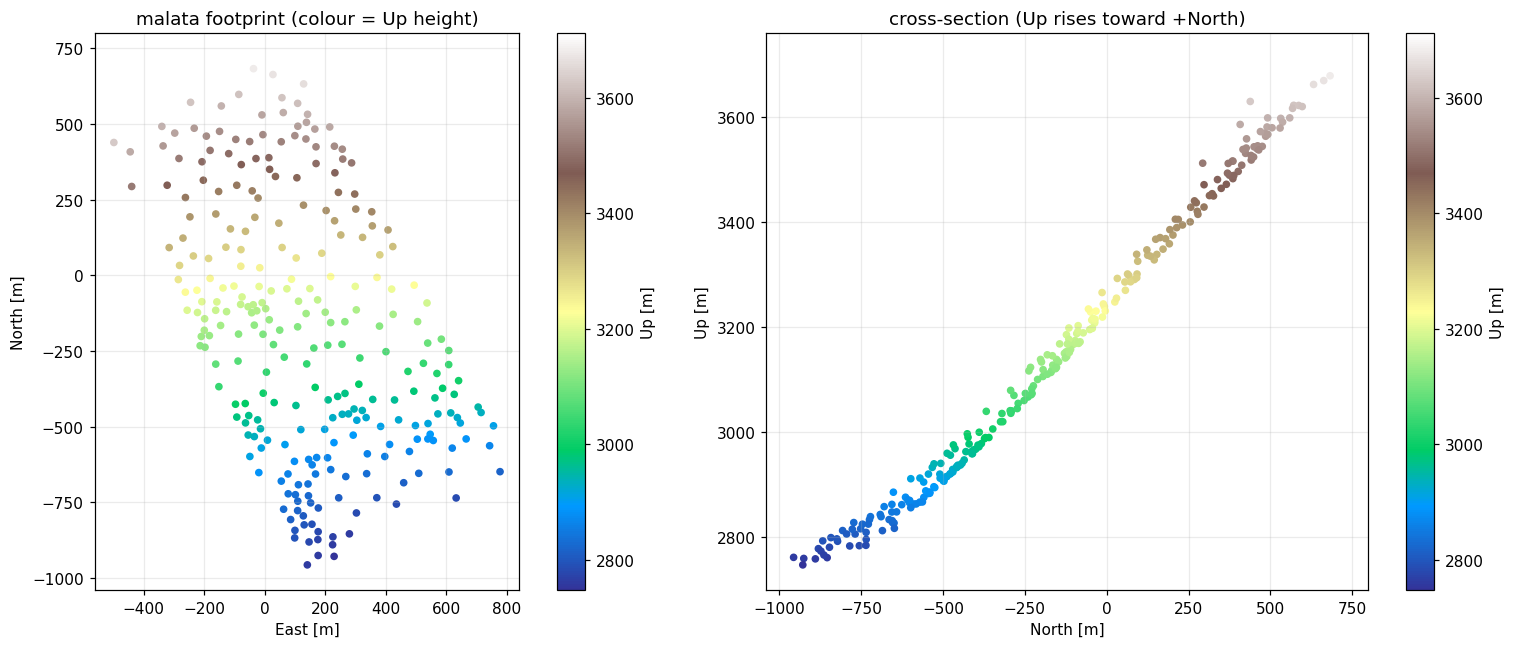

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
# Right-handed ENU map: East = x (right), North = y (up).
sc = ax[0].scatter(mE, mN, c=mU, s=16, cmap="terrain")
ax[0].set(xlabel="East [m]", ylabel="North [m]", title="malata footprint (colour = Up height)")
ax[0].set_aspect("equal"); plt.colorbar(sc, ax=ax[0], label="Up [m]")
# Cross-section: the slope rises with North (Up-North corr +0.99), so view Up vs North.
sc = ax[1].scatter(mN, mU, c=mU, s=16, cmap="terrain")
ax[1].set(xlabel="North [m]", ylabel="Up [m]", title="cross-section (Up rises toward +North)")
plt.colorbar(sc, ax=ax[1], label="Up [m]")
fig.tight_layout(); plt.show()

## 1b · The mountain in 3D

The actual triangulated detector-region surface (not just centroids), rebuilt from the mesh
vertices/faces in ENU — colour and height are `Up`. The `grid` detector layout is dropped on the
surface (black triangles). Axes are drawn to physical scale, so the ≈1 km of relief across the
≈1.7 km × 1.3 km footprint shows the real slope the showers develop over.


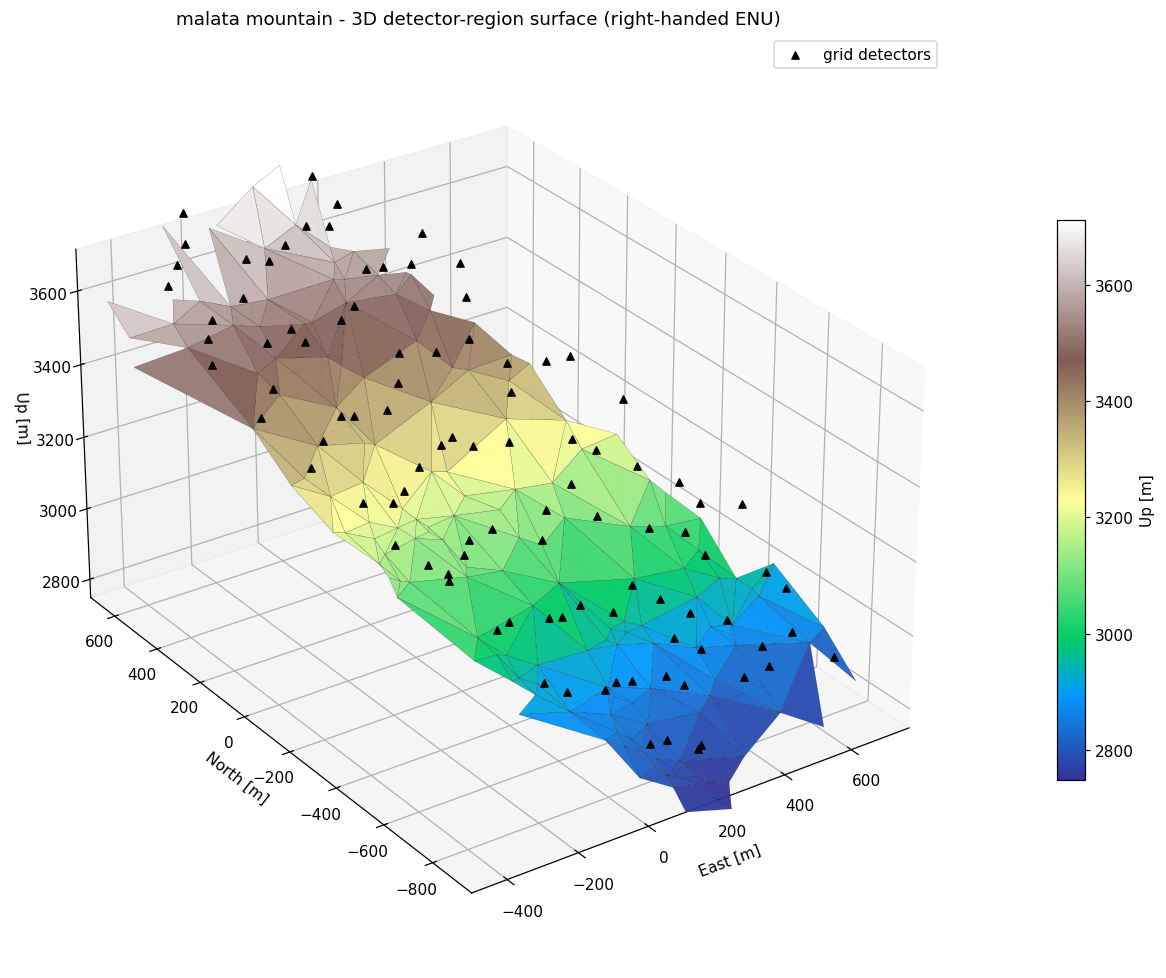

In [4]:
import matplotlib
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from modules_v4.tr_geometry import _ecef_to_enu   # ECEF->ENU, rows [East, North, Up]

# Rebuild the detector-region TRIANGLES (not centroids) in ENU about the mesh origin.
with h5py.File(GEOMETRY_PATH_RESOLVED, "r") as f:
    g = f[GEOMETRY_GROUP]
    _verts = g["vertices"][...]; _faces = g["faces"][...] - 1
    _det   = g[DET_KEY][...] - 1; _loc = g["location"][...]
_tri_ecef = _verts[:, _faces[:, _det]]
_enu = _ecef_to_enu(_tri_ecef.reshape(3, -1), float(_loc[0]), float(_loc[1]))
_E3, _N3, _U3 = (_enu[i].reshape(3, -1) for i in range(3))
# RIGHT-HANDED ENU axes: x=East, y=North, z=Up  (E x N = U).
tris   = np.stack([_E3, _N3, _U3], axis=-1).transpose(1, 0, 2)   # (Ndet, 3 vert, [E,N,Up])
tri_up = _U3.mean(axis=0)

norm = matplotlib.colors.Normalize(tri_up.min(), tri_up.max())
poly = Poly3DCollection(tris, facecolors=matplotlib.cm.terrain(norm(tri_up)),
                        edgecolors="k", linewidths=0.1, alpha=0.95)

fig = plt.figure(figsize=(13, 9))
ax = fig.add_subplot(111, projection="3d")
ax.add_collection3d(poly)
Eg, Ng = layouts["grid"]            # (East, North)
ax.scatter(Eg, Ng, det_up(Ng, Eg)+110, c="black", s=22, marker="^",
           depthshade=False, label="grid detectors")
ax.set_xlim(mE.min(), mE.max()); ax.set_ylim(mN.min(), mN.max()); ax.set_zlim(mU.min(), mU.max())
ax.set_box_aspect((np.ptp(mE), np.ptp(mN), np.ptp(mU)))   # physical scale
ax.set_xlabel("East [m]"); ax.set_ylabel("North [m]"); ax.set_zlabel("Up [m]")
ax.set_title("malata mountain - 3D detector-region surface (right-handed ENU)"); ax.legend()
ax.view_init(elev=28, azim=-125)
sm = matplotlib.cm.ScalarMappable(norm=norm, cmap="terrain"); sm.set_array([])
fig.colorbar(sm, ax=ax, shrink=0.6, pad=0.08, label="Up [m]")
fig.tight_layout(); plt.show()

## 2 · Tau decays over the mountain (`tau_wholesky.h5`)

**Per J. Lazar:** the file holds *both* an **observation section** (`detector1`, ≈1.4 km, the
detector footprint) *and* the **full earth terrain**. Tau decays happen across the terrain, not
just the footprint — 95% land within ~9 km of the site (tail to 181 km). Earlier plots drew decays
only on the 1.4 km footprint, so they looked pinned to its edge. Below they are shown on the **real
local terrain** (`add_terrain`, all mesh faces within ±15 km — ~98% of decays), which the
Earth-skimming taus graze as they emerge from the rock.

Left: **all** decays in the (East, North) map (grey = outside the observation box, red = inside).
Right: the **local terrain surface** with the decays sitting on it.

decays: 54192 in obs box, 746817 on local terrain, 751931 total


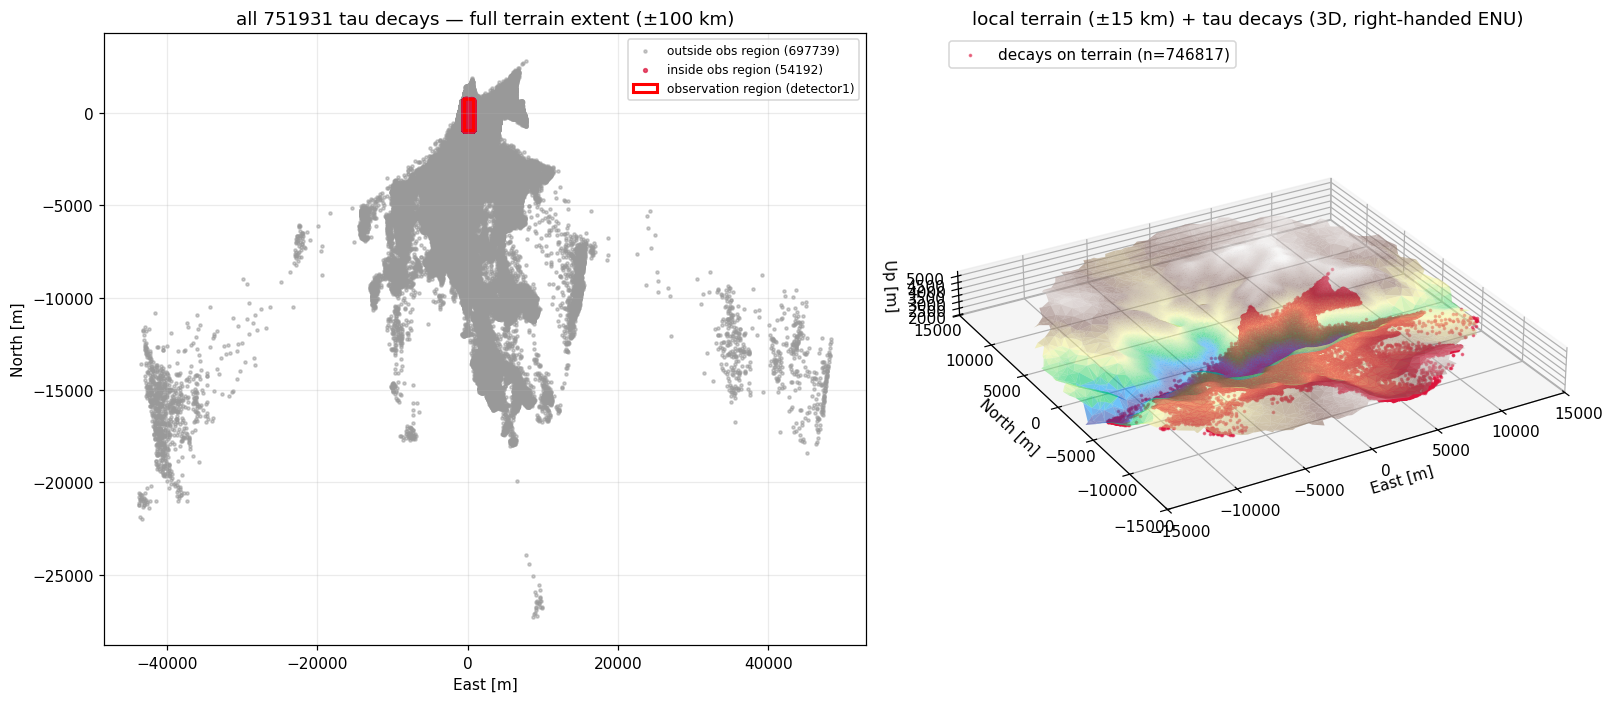

In [5]:
in_obs = (tE_e>=mE.min())&(tE_e<=mE.max())&(tN_n>=mN.min())&(tN_n<=mN.max())
sel = near_mtn  # in_obs is empty under the --mindist cut (see cell 3)
print(f"decays: {int(in_obs.sum())} in obs box, {int(on_terr.sum())} on local terrain, {tE_e.size} total")

fig = plt.figure(figsize=(15, 6.5))

# Left: ALL decays, full terrain extent; observation region drawn only as a small box.
ax0 = fig.add_subplot(1, 2, 1)
ax0.scatter(tE_e[~in_obs], tN_n[~in_obs], s=4, c="0.6", alpha=0.5,
            label=f"outside obs region ({int((~in_obs).sum())})")
ax0.scatter(tE_e[in_obs], tN_n[in_obs], s=6, c="crimson", alpha=0.7,
            label=f"inside obs region ({int(in_obs.sum())})")
ax0.add_patch(Rectangle((mE.min(), mN.min()), mE.max()-mE.min(), mN.max()-mN.min(),
                        fill=False, ec="red", lw=2, label="observation region (detector1)"))
ax0.set(xlabel="East [m]", ylabel="North [m]",
        title=f"all {tpos.shape[1]} tau decays — full terrain extent (±100 km)")
ax0.legend(loc="upper right", fontsize=8)

# Right: the REAL local terrain (±15 km) with the decays that sit on it — spread across
# the whole valley/ridge, not pinned to the 1.4 km observation footprint.
ax1 = fig.add_subplot(1, 2, 2, projection="3d")
add_terrain(ax1, alpha=0.55)
ax1.scatter(tE_e[on_terr], tN_n[on_terr], tU_u[on_terr], s=2, c="crimson",
            alpha=0.5, depthshade=False, label=f"decays on terrain (n={int(on_terr.sum())})")
ax1.set_xlabel("East [m]"); ax1.set_ylabel("North [m]"); ax1.set_zlabel("Up [m]")
ax1.set_title(f"local terrain (±{LOC_R/1e3:.0f} km) + tau decays (3D, right-handed ENU)")
ax1.view_init(elev=28, azim=-120); ax1.legend(loc="upper left")
fig.tight_layout(); plt.show()

## 2b · Tau arrival directions (vector field)

Each near-mountain tau's **travel direction** (a UNIT vector, |d|=1) drawn as an arrow at its decay point, in the right-handed ENU frame (x=East, y=North, z=Up). Coloured by Up-component (blue = down-going, red = up-going). Mostly near-horizontal, slightly up-going (mean +0.09), with a northward lean — Earth-skimming geometry.

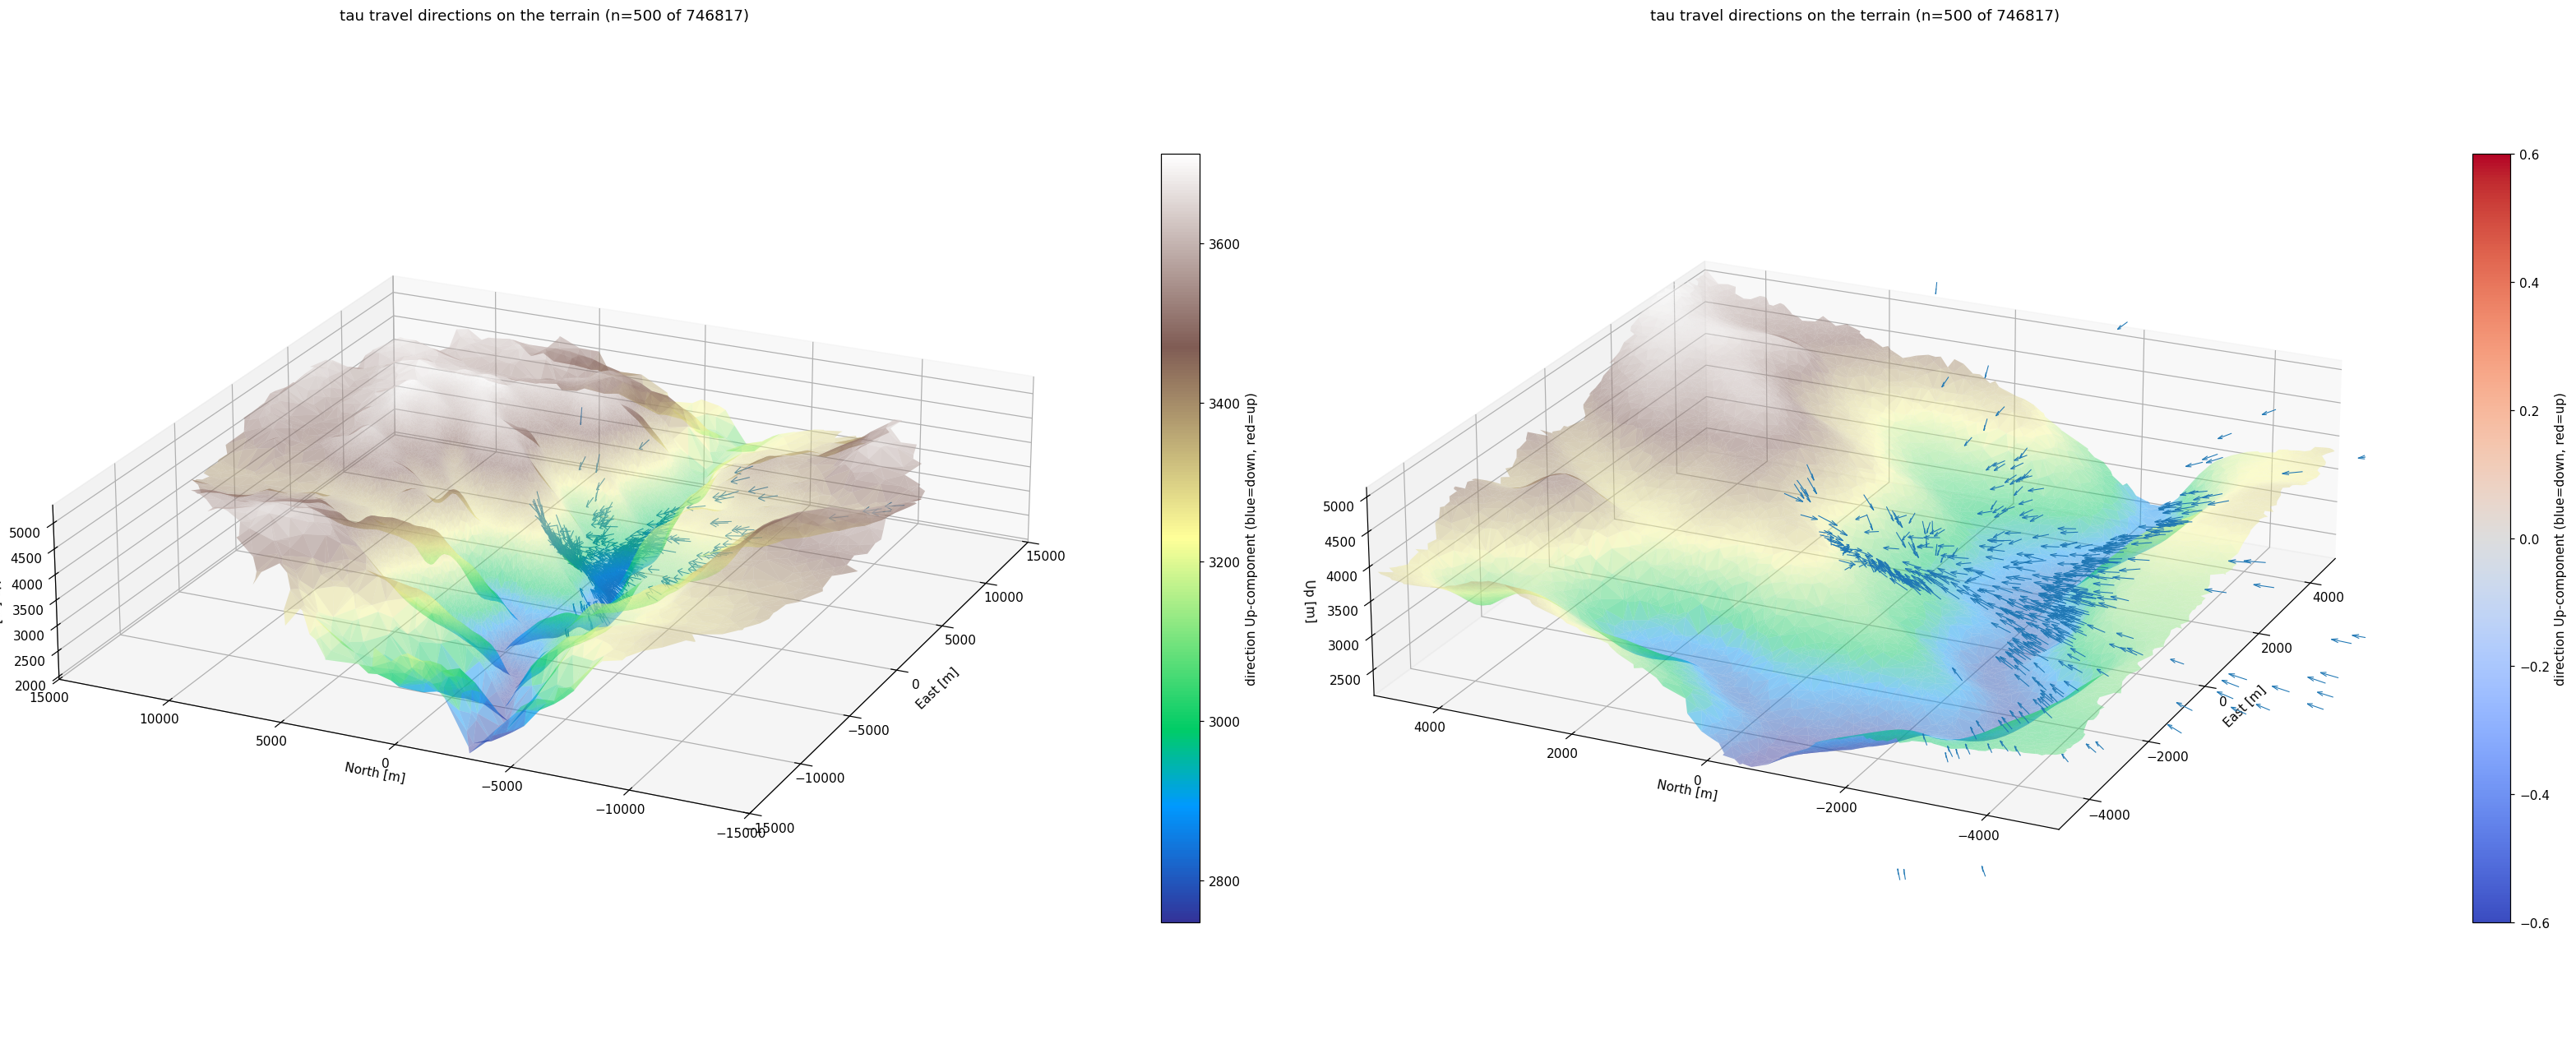

In [6]:
# Tau directions are UNIT vectors (|d| = 1.000000 exactly; ENU rows = East, North, Up).
with h5py.File(TAU_WHOLESKY_PATH, "r") as f:
    tdir = f["direction"][...]                 # (3, N)
dE, dN, dU = tdir[0], tdir[1], tdir[2]         # East, North, Up components (dimensionless cosines)

idx = np.where(on_terr)[0]                      # taus on the local terrain (±15 km)
qrng = np.random.default_rng(0)
q = qrng.choice(idx, size=min(500, idx.size), replace=False)   # subsample for legibility

fig = plt.figure(figsize=(30, 15))
ax0 = fig.add_subplot(1, 2, 1, projection="3d")

add_terrain(ax0, alpha=0.45)

# RIGHT-HANDED axes x=East, y=North, z=Up; arrow = tau travel direction, colour = Up-component.
cmap = plt.cm.coolwarm; cn = plt.Normalize(-0.6, 0.6); cols = cmap(cn(dU[q]))
ax0.quiver(tE_e[q], tN_n[q], tU_u[q], dE[q], dN[q], dU[q],
           length=800.0, normalize=True, linewidth=0.7, arrow_length_ratio=0.35)

ax0.set_xlabel("East [m]"); ax0.set_ylabel("North [m]"); ax0.set_zlabel("Up [m]")
ax0.set_title(f"tau travel directions on the terrain (n={q.size} of {idx.size})")
ax0.view_init(elev=22, azim=-155)
ax0.set_box_aspect((1, 1, 0.25)) 
fig.colorbar(sm, ax=ax0, shrink=0.6, pad=0.08, label="direction Up-component (blue=down, red=up)")


ax1 = fig.add_subplot(1, 2, 2, projection="3d")

add_terrain(ax1, alpha=0.45, r_lim=5000.0)

# RIGHT-HANDED axes x=East, y=North, z=Up; arrow = tau travel direction, colour = Up-component.
cmap = plt.cm.coolwarm; cn = plt.Normalize(-0.6, 0.6); cols = cmap(cn(dU[q]))
ax1.quiver(tE_e[q], tN_n[q], tU_u[q], dE[q], dN[q], dU[q],
           length=300.0, normalize=True, linewidth=0.7, arrow_length_ratio=0.35)

ax1.set_xlabel("East [m]"); ax1.set_ylabel("North [m]"); ax1.set_zlabel("Up [m]")
ax1.set_title(f"tau travel directions on the terrain (n={q.size} of {idx.size})")
ax1.view_init(elev=22, azim=-155)
sm = plt.cm.ScalarMappable(norm=cn, cmap=cmap); sm.set_array([])

fig.colorbar(sm, ax=ax1, shrink=0.6, pad=0.08, label="direction Up-component (blue=down, red=up)")
fig.tight_layout(pad=3.0); 
# fig.subplots_adjust(left=2)   # more space between side-by-side plots

plt.show()

## 3 · Detectors over the mountain

The `04` optimizers seed from these initial (East, North) layout strategies, each projected onto the
mountain surface. Left: four strategies in the footprint. Right: the `grid` layout lifted onto the
surface height in the (North, Up) cross-section.


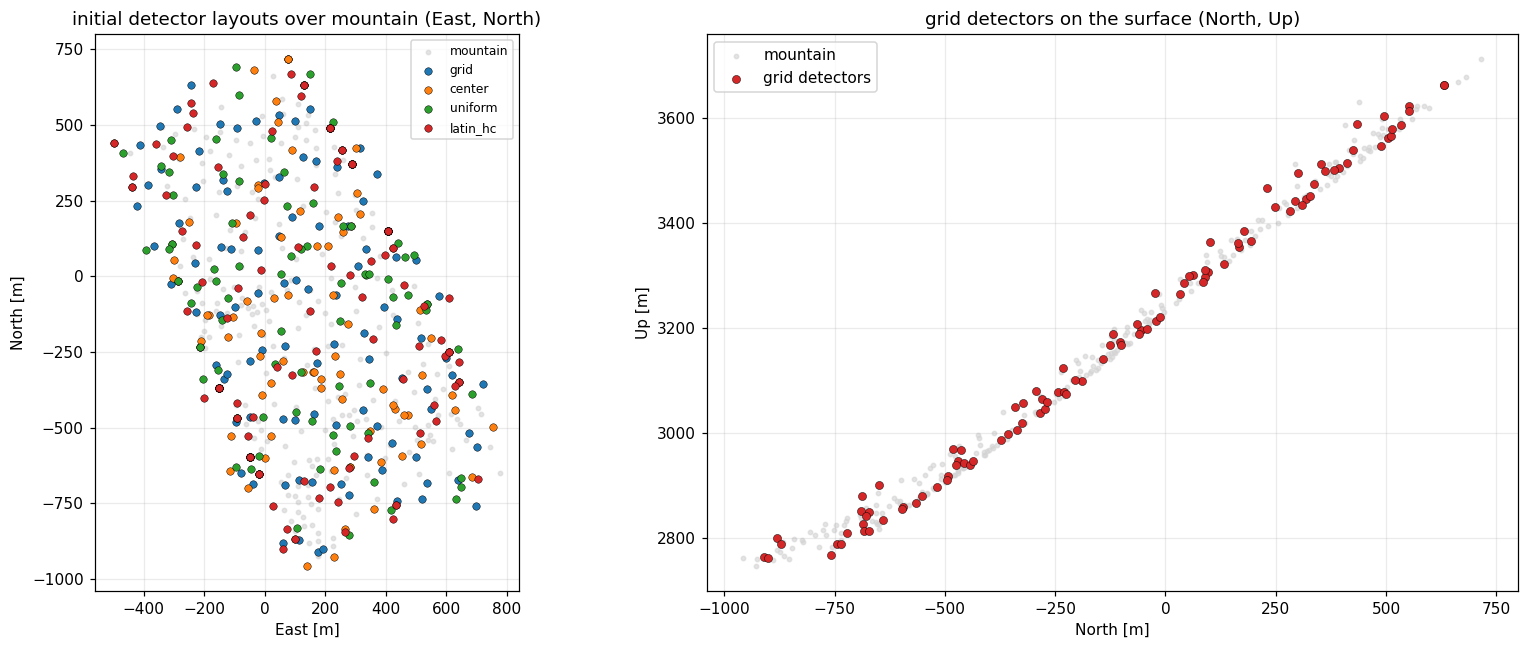

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
# Right-handed ENU map: East = x, North = y.
ax[0].scatter(mE, mN, s=8, c="lightgray", alpha=0.6, label="mountain", zorder=0)
for name, (E_, N_) in layouts.items():
    ax[0].scatter(E_, N_, s=24, edgecolors="k", linewidths=0.3, label=name, zorder=2)
ax[0].set(xlabel="East [m]", ylabel="North [m]", aspect="equal",
          title="initial detector layouts over mountain (East, North)")
ax[0].legend(loc="upper right", fontsize=8)

ax[1].scatter(mN, mU, s=8, c="lightgray", alpha=0.6, label="mountain", zorder=0)
E_, N_ = layouts["grid"]
ax[1].scatter(N_, det_up(N_, E_), s=28, c="C3", edgecolors="k", linewidths=0.3,
              label="grid detectors", zorder=2)
ax[1].set(xlabel="North [m]", ylabel="Up [m]",
          title="grid detectors on the surface (North, Up)"); ax[1].legend()
fig.tight_layout(); plt.show()

## 4 · Combined overlay

Mountain height + illuminating tau decays + a detector layout, in both projections — the geometry the
FNN surrogate and the layout optimizer actually see.


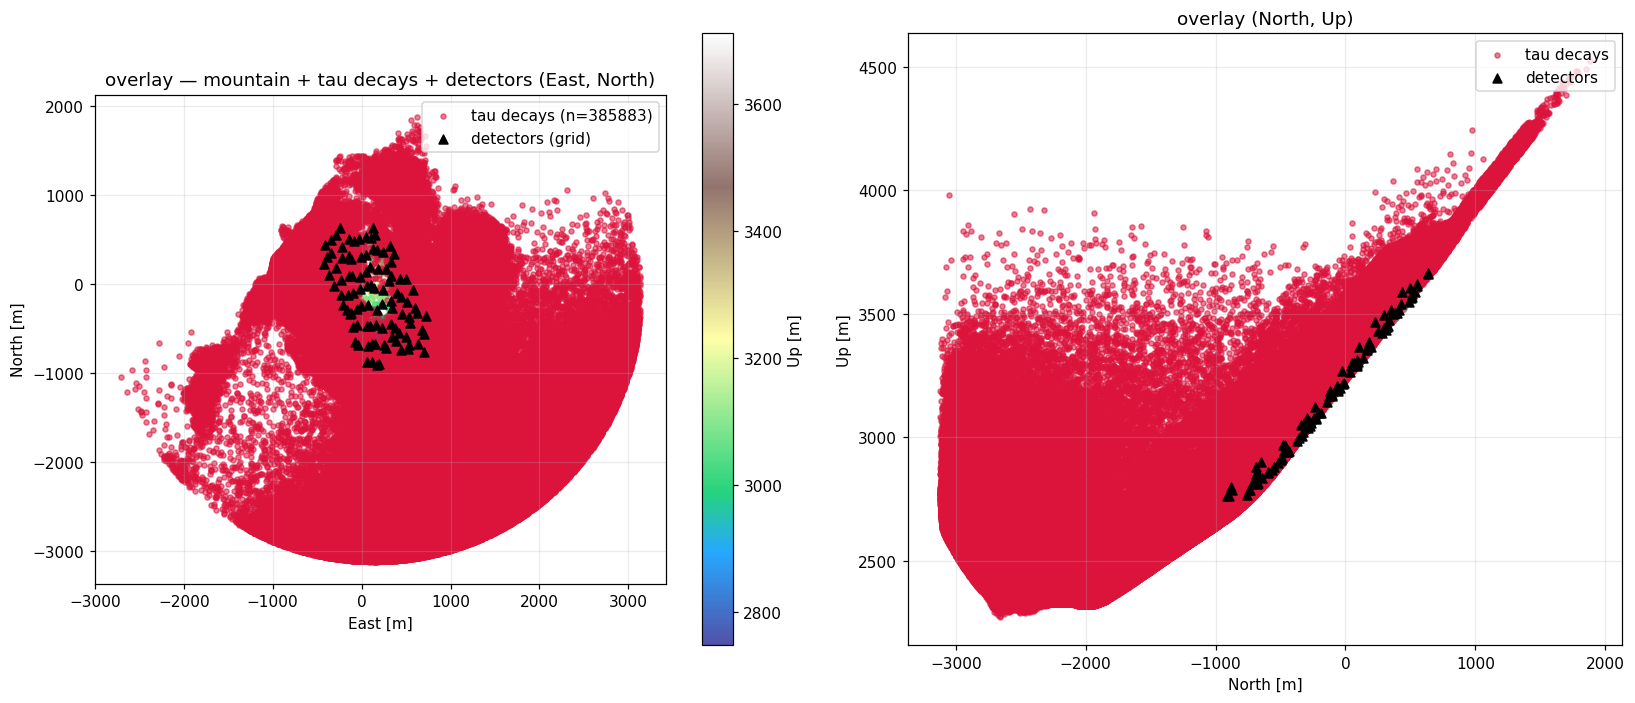

In [8]:
E_, N_ = layouts["grid"]
fig, ax = plt.subplots(1, 2, figsize=(15, 6.5))
# Right-handed ENU map: East = x, North = y.
sc = ax[0].scatter(mE, mN, c=mU, s=22, cmap="terrain", alpha=0.85, zorder=0)
ax[0].scatter(tE_e[sel], tN_n[sel], s=11, c="crimson", alpha=0.55,
              label=f"tau decays (n={int(sel.sum())})", zorder=1)
ax[0].scatter(E_, N_, s=34, c="black", marker="^", label="detectors (grid)", zorder=2)
ax[0].set(xlabel="East [m]", ylabel="North [m]", aspect="equal",
          title="overlay — mountain + tau decays + detectors (East, North)")
ax[0].legend(loc="upper right"); plt.colorbar(sc, ax=ax[0], label="Up [m]")

sc = ax[1].scatter(mN, mU, c=mU, s=22, cmap="terrain", alpha=0.75, zorder=0)
ax[1].scatter(tN_n[sel], tU_u[sel], s=11, c="crimson", alpha=0.55, label="tau decays", zorder=1)
ax[1].scatter(N_, det_up(N_, E_), s=34, c="black", marker="^", label="detectors", zorder=2)
ax[1].set(xlabel="North [m]", ylabel="Up [m]",
          title="overlay (North, Up)"); ax[1].legend(loc="upper right")
fig.tight_layout(); plt.show()

## 5 - Shower placement transformation (demo)

How one shower maps into ENU. Real point clouds come from the AllShowers generator (GPU); here an
illustrative rod is put through the **exact Step-1 transform**: its transverse (x, y) becomes
(North, Up) at the decay, and its `layer_index` becomes East depth via
`East = east_entry - layer*layer_dx`. Left: the placed shower on the mountain in 3D ENU (colour =
layer/depth). Right: the transverse (North, Up) plane the kernel matches detectors in - the rod is
compact there, its length lives entirely along East (the depth axis).

demo decay  East=46  North=-19  Up=3273


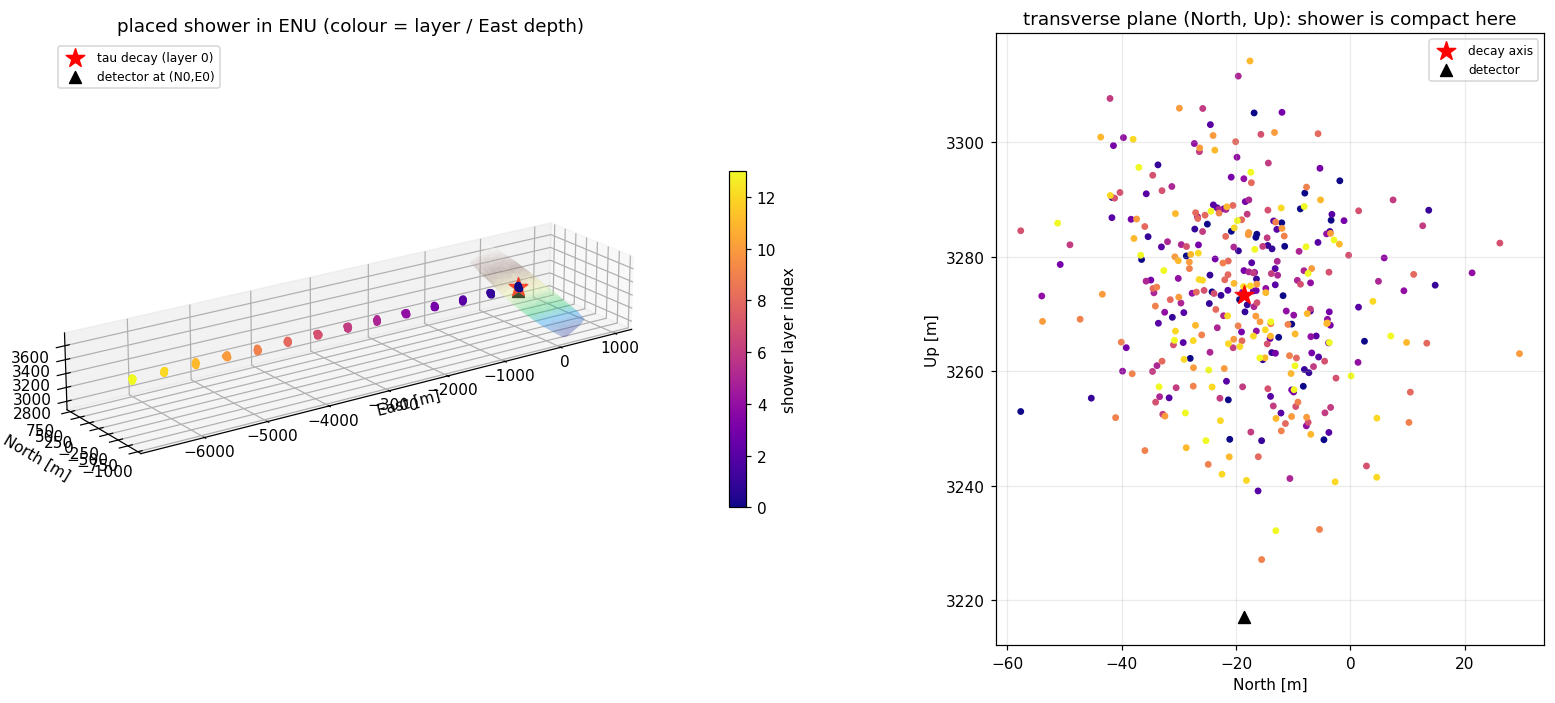

In [9]:
from modules_v6.constants import EAST_ENTRY, LAYER_EAST_DX
import torch

# Pick a real near-mountain tau decay closest to the footprint centre.
cN, cE = 0.5*(mN.min()+mN.max()), 0.5*(mE.min()+mE.max())
# No decay sits inside the footprint under the --mindist cut, so take the
# in-band decay CLOSEST to its centre rather than requiring one inside.
ci = np.where(inband)[0]
j = ci[np.argmin((tN_n[ci]-cN)**2 + (tE_e[ci]-cE)**2)]
E0, N0, U0 = float(tE_e[j]), float(tN_n[j]), float(tU_u[j])
print(f"demo decay  East={E0:.0f}  North={N0:.0f}  Up={U0:.0f}")

# Illustrative rod: transverse gaussian (~15 m) x 14 longitudinal layers.
nlay, per = 14, 25
lay = np.repeat(np.arange(nlay), per).astype(np.float32)
rng = np.random.default_rng(1)
cloud = np.zeros((1, lay.size, 5), np.float32)
cloud[0,:,0] = rng.normal(0, 15, lay.size)   # transverse x
cloud[0,:,1] = rng.normal(0, 15, lay.size)   # transverse y
cloud[0,:,2] = lay                            # layer_index (depth)
cloud[0,:,3] = 1.0; cloud[0,:,4] = 1.0
c = torch.tensor(cloud)

# EXACT Step-1 placement: transverse centroid -> (N0, U0); layer shift for real East.
m = (c[:,:,3]>0).float(); w = m.sum(1).clamp(min=1)
cx = (c[:,:,0]*m).sum(1)/w; cy = (c[:,:,1]*m).sum(1)/w
c[...,0] += (N0 - cx.view(-1,1))*m                       # col0 -> North
c[...,1] += (U0 - cy.view(-1,1))*m                       # col1 -> Up
c[...,2] += (EAST_ENTRY - E0)/LAYER_EAST_DX * m          # layer -> real East depth

sN  = c[0,:,0].numpy(); sUp = c[0,:,1].numpy()
sE  = EAST_ENTRY - c[0,:,2].numpy()*LAYER_EAST_DX        # point East from layer
detUp = float(det_up(np.array([N0]), np.array([E0]))[0]) # detector height on the terrain

fig = plt.figure(figsize=(15, 6.5))

# Left: placed shower on the mountain, right-handed ENU (x=East, y=North, z=Up).
ax0 = fig.add_subplot(1, 2, 1, projection="3d")
ax0.plot_trisurf(mE, mN, mU, cmap="terrain", alpha=0.35, linewidth=0)
p0 = ax0.scatter(sE, sN, sUp, c=lay, cmap="plasma", s=10, depthshade=False)
ax0.scatter([E0],[N0],[U0], c="red", s=160, marker="*", depthshade=False, label="tau decay (layer 0)")
ax0.scatter([E0],[N0],[detUp], c="black", s=60, marker="^", depthshade=False, label="detector at (N0,E0)")
ax0.set_box_aspect((np.ptp(np.r_[sE, mE]), np.ptp(mN), np.ptp(mU)))
ax0.set_xlabel("East [m]"); ax0.set_ylabel("North [m]"); ax0.set_zlabel("Up [m]")
ax0.set_title("placed shower in ENU (colour = layer / East depth)")
ax0.view_init(elev=20, azim=-125); ax0.legend(loc="upper left", fontsize=8)
fig.colorbar(p0, ax=ax0, shrink=0.55, pad=0.10, label="shower layer index")

# Right: the transverse (North, Up) plane - the kernel's matching plane.
ax1 = fig.add_subplot(1, 2, 2)
ax1.scatter(sN, sUp, c=lay, cmap="plasma", s=12)
ax1.scatter([N0],[U0], c="red", s=160, marker="*", label="decay axis")
ax1.scatter([N0],[detUp], c="black", s=60, marker="^", label="detector")
ax1.set(xlabel="North [m]", ylabel="Up [m]", aspect="equal",
        title="transverse plane (North, Up): shower is compact here")
ax1.legend(fontsize=8)
fig.tight_layout(); plt.show()

## 6 · Mountain surface directions (normals)

The slope the showers develop over, as a **direction field**. Per detector-region triangle we take
the ENU surface normal (`cross` of two edges, oriented Up), so its tilt from vertical is the local
steepness and its horizontal projection is the downslope-facing **aspect**. The malata face is a
fairly uniform ramp: ≈32° tilt, normals leaning consistently toward one quadrant — the taus emerge
roughly along this ramp (next section).

slope tilt: median 32.1 deg, p90 35.9, max 39.4


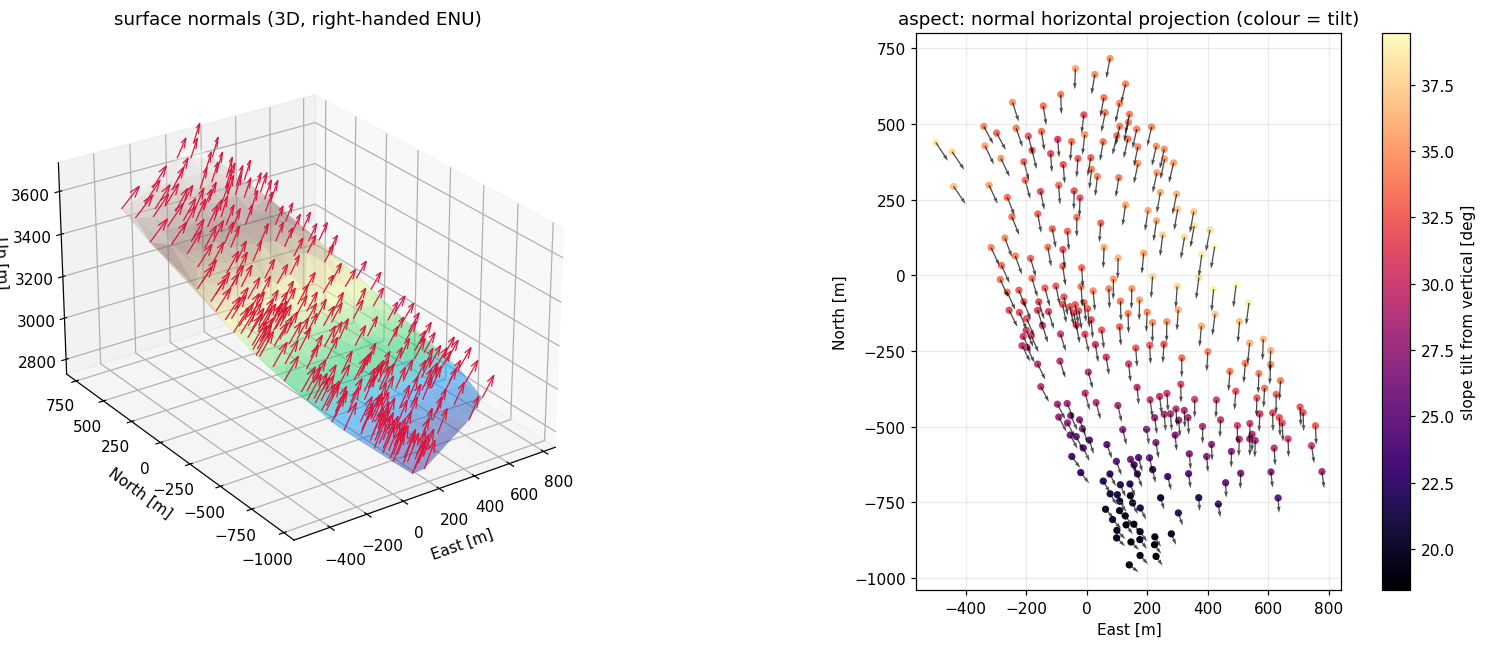

In [10]:
# Per-face ENU surface normals from the triangles rebuilt in section 1b (`tris`).
v0, v1, v2 = tris[:, 0], tris[:, 1], tris[:, 2]
nrm = np.cross(v1 - v0, v2 - v0)
nrm /= np.linalg.norm(nrm, axis=1, keepdims=True) + 1e-12
nrm[nrm[:, 2] < 0] *= -1.0                                   # orient upward (Up>0)
cen = tris.mean(axis=1)                                      # triangle centroids [E, N, Up]
slope_deg = np.degrees(np.arccos(np.clip(nrm[:, 2], -1, 1)))  # tilt from vertical
print(f"slope tilt: median {np.median(slope_deg):.1f} deg, "
      f"p90 {np.percentile(slope_deg,90):.1f}, max {slope_deg.max():.1f}")

fig = plt.figure(figsize=(15, 6))
# Left: 3D surface normals (right-handed ENU, x=East y=North z=Up).
ax = fig.add_subplot(1, 2, 1, projection="3d")
ax.plot_trisurf(mE, mN, mU, cmap="terrain", alpha=0.5, linewidth=0)
s = slice(None, None, max(1, len(cen) // 200))
ax.quiver(cen[s,0], cen[s,1], cen[s,2], nrm[s,0], nrm[s,1], nrm[s,2],
          length=150.0, normalize=True, color="crimson", linewidth=0.8, arrow_length_ratio=0.4)
ax.set_box_aspect((np.ptp(mE), np.ptp(mN), np.ptp(mU)))
ax.set_xlabel("East [m]"); ax.set_ylabel("North [m]"); ax.set_zlabel("Up [m]")
ax.set_title("surface normals (3D, right-handed ENU)"); ax.view_init(elev=26, azim=-125)

# Right: 2D aspect map — normal's horizontal projection = downslope-facing direction.
ax2 = fig.add_subplot(1, 2, 2)
sc = ax2.scatter(cen[:,0], cen[:,1], c=slope_deg, s=14, cmap="magma")
ax2.quiver(cen[s,0], cen[s,1], nrm[s,0], nrm[s,1], color="k",
           angles="xy", scale=12, width=0.003, alpha=0.7)
ax2.set(xlabel="East [m]", ylabel="North [m]", aspect="equal",
        title="aspect: normal horizontal projection (colour = tilt)")
plt.colorbar(sc, ax=ax2, label="slope tilt from vertical [deg]")
fig.tight_layout(); plt.show()

## 7 · Tau directions vs the surface (earth-skimming geometry)

Ties the two direction fields together. For each near-mountain tau we take its travel direction (unit
vector, section 2b) and the **local surface normal** (nearest triangle from section 6), and measure the
tau's elevation relative to that surface: `arcsin(d·n)`, where **0° = travelling parallel to the
slope**. The distribution piles up at ≈0° (median ≈3°, ~90% within ±10°) — the defining signature of
Earth-skimming taus grazing out of the rock. Navy = tau travel, red = surface normal.

elevation vs local surface: median 1.1 deg, within +-10 deg: 80%


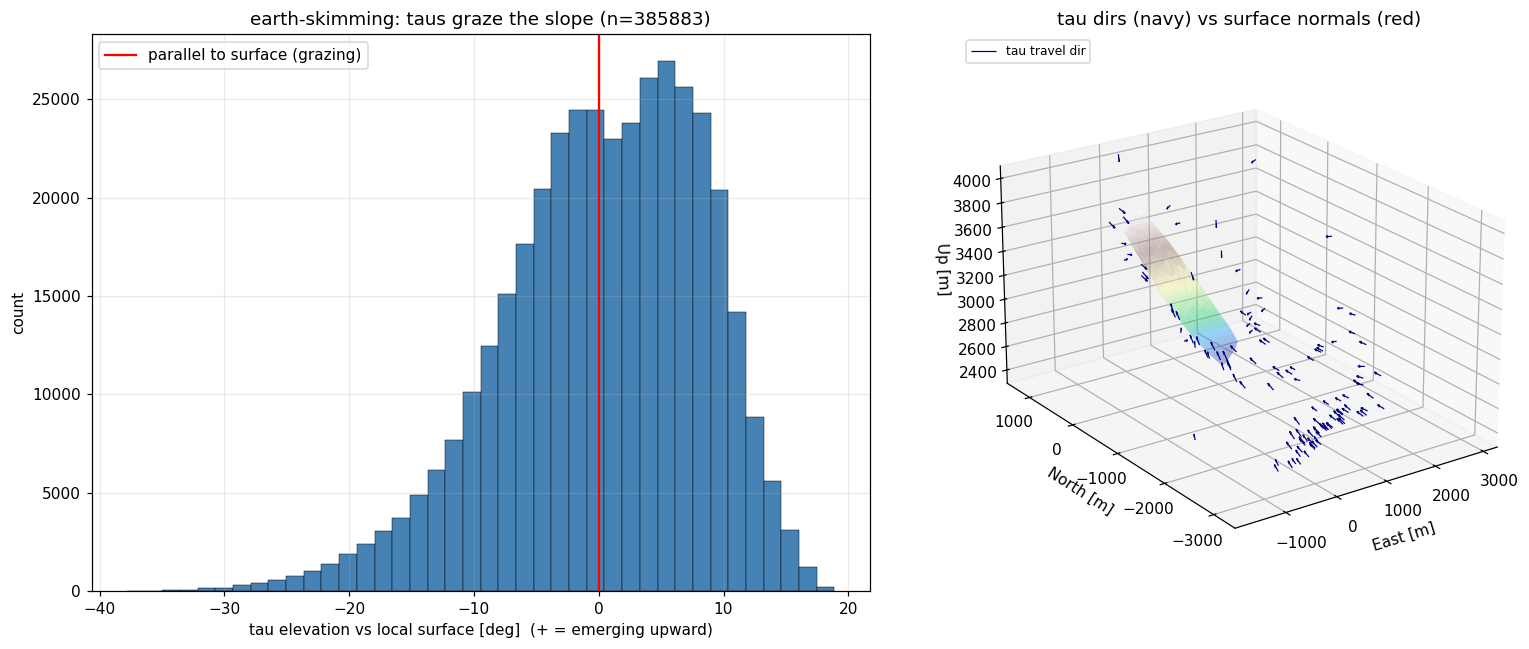

In [ ]:
onmtn = near_mtn   # was the obs bbox, empty under the --mindist cut (cell 3)
idx = np.where(onmtn)[0]
# nearest triangle centroid -> its normal, per near-mountain tau.
nn = (((cen[None,:,0]-tE_e[idx,None])**2 + (cen[None,:,1]-tN_n[idx,None])**2)).argmin(axis=1)
dvec = np.stack([dE[idx], dN[idx], dU[idx]], axis=1)          # unit travel dirs (section 2b)
ncos = np.einsum("ij,ij->i", dvec, nrm[nn])                   # d . n
elev_deg = np.degrees(np.arcsin(np.clip(ncos -1, 1)))        # + = emerging upward out of rock
print(f"elevation vs local surface: median {np.median(elev_deg):.1f} deg, "
      f"within +-10 deg: {np.mean(np.abs(elev_deg)<10):.0%}")

fig = plt.figure(figsize=(15, 6))
axh = fig.add_subplot(1, 2, 1)
axh.hist(elev_deg, bins=40, color="steelblue", edgecolor="k", lw=0.3)
axh.axvline(0, color="red", lw=1.5, label="parallel to surface (grazing)")
axh.set(xlabel="tau elevation vs local surface [deg]  (+ = emerging upward)", ylabel="count",
        title=f"earth-skimming: taus graze the slope (n={idx.size})"); axh.legend()

ax3 = fig.add_subplot(1, 2, 2, projection="3d")
ax3.plot_trisurf(mE, mN, mU, cmap="terrain", alpha=0.4, linewidth=0)
qs = idx[::max(1, idx.size // 120)]
ax3.quiver(tE_e[qs], tN_n[qs], tU_u[qs], dE[qs], dN[qs], dU[qs], length=100, normalize=True,
           color="navy", linewidth=0.8, arrow_length_ratio=0.35, label="tau travel dir")
nnq = nn[np.searchsorted(idx, qs)]
# ax3.quiver(cen[nnq,0], cen[nnq,1], cen[nnq,2], nrm[nnq,0], nrm[nnq,1], nrm[nnq,2], length=100,
#            normalize=True, color="crimson", linewidth=0.8, arrow_length_ratio=0.4, label="surface normal")
ax3.set_box_aspect((np.ptp(mE), np.ptp(mN), np.ptp(mU)))
ax3.set_xlabel("East [m]"); ax3.set_ylabel("North [m]"); ax3.set_zlabel("Up [m]")
ax3.set_title("tau dirs (navy) vs surface normals (red)"); ax3.view_init(elev=22, azim=-125)
ax3.legend(loc="upper left", fontsize=8)
fig.tight_layout(); plt.show()

## 8 · The formerly-different coordinate systems → one ENU frame

The concrete version of the table in section 0: each source arrives in its **own** frame and is mapped
into the shared site-local ENU. Top row — the mountain as it lives in `malata.h5` (**geocentric ECEF**,
±1000s of km offsets) vs the same triangles after `_ecef_to_enu` about the mesh origin (**metres, site
origin**). Bottom row — one shower in its **native transverse rod** frame `(x, y, layer_index)` vs the
same rod placed at a real tau decay in ENU (`x→North`, `y→Up`, `layer→East` depth). Tau positions and
directions in `tau_wholesky.h5` are already ENU, so they need no transform.

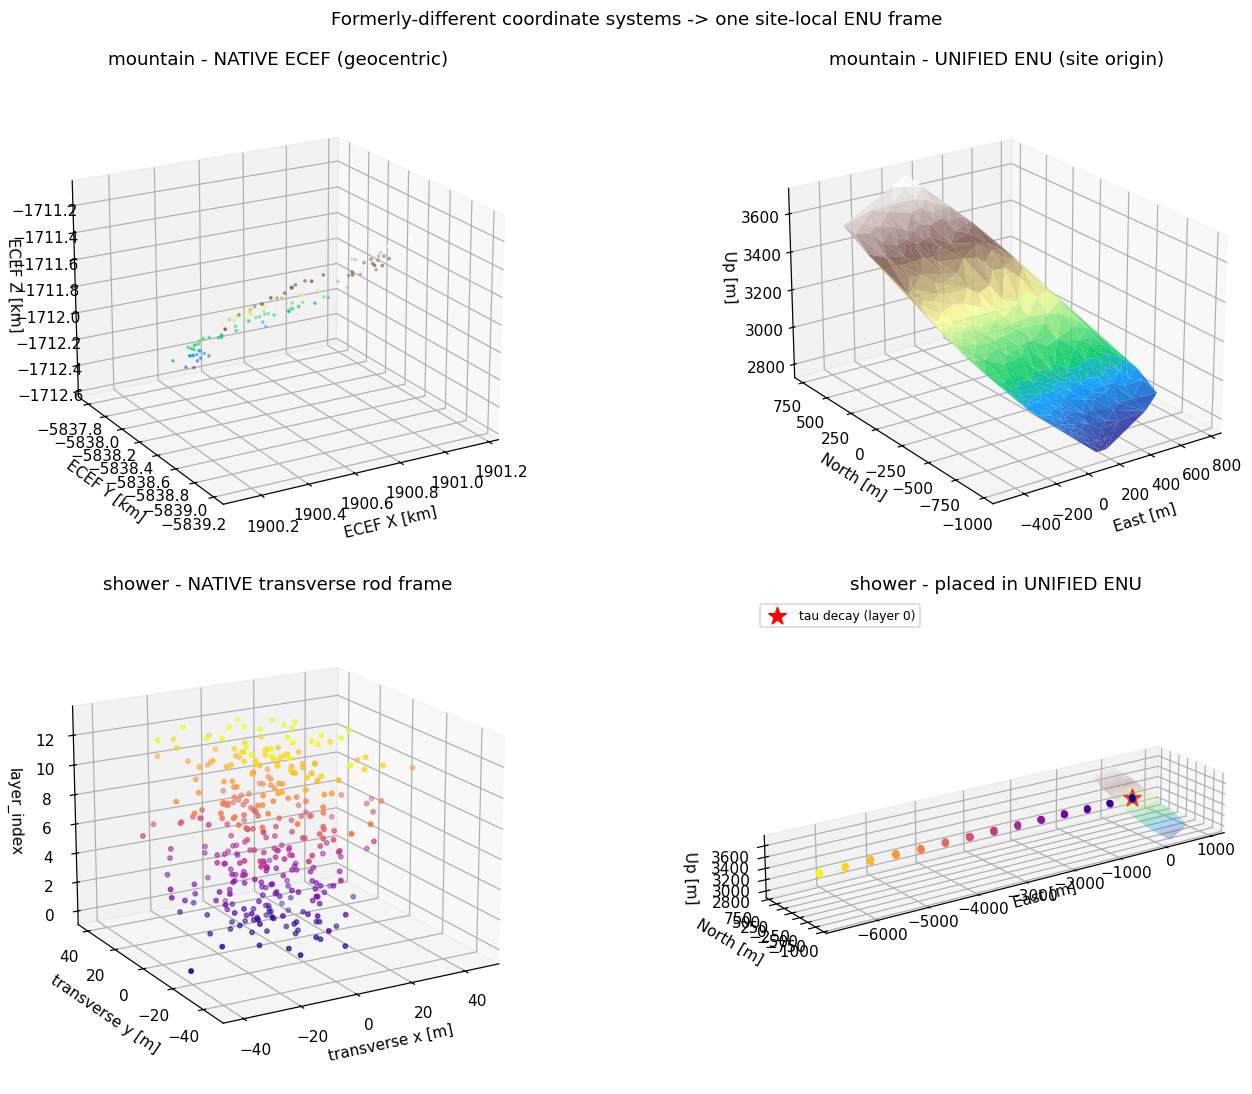

In [12]:
from mpl_toolkits.mplot3d.art3d import Poly3DCollection  # noqa
from modules_v4.tr_geometry import _ecef_to_enu  # noqa

# Raw ECEF detector-region triangle vertices (native mountain frame).
with h5py.File(GEOMETRY_PATH_RESOLVED, "r") as f:
    g = f[GEOMETRY_GROUP]
    _v = g["vertices"][...]; _fc = g["faces"][...] - 1; _dk = g[DET_KEY][...] - 1
_tri_ecef = _v[:, _fc[:, _dk]]                                # (3, 3vert, Ndet) ECEF metres
ex, ey, ez = (_tri_ecef[i].reshape(-1) for i in range(3))

fig = plt.figure(figsize=(15, 10))
# A: mountain NATIVE ECEF (geocentric).
axA = fig.add_subplot(2, 2, 1, projection="3d")
axA.scatter(ex[::7]/1e3, ey[::7]/1e3, ez[::7]/1e3, s=2, c=ez[::7], cmap="terrain")
axA.set_xlabel("ECEF X [km]"); axA.set_ylabel("ECEF Y [km]"); axA.set_zlabel("ECEF Z [km]")
axA.set_title("mountain - NATIVE ECEF (geocentric)"); axA.view_init(elev=20, azim=-120)
# B: mountain UNIFIED ENU.
axB = fig.add_subplot(2, 2, 2, projection="3d")
axB.plot_trisurf(mE, mN, mU, cmap="terrain", alpha=0.9, linewidth=0)
axB.set_box_aspect((np.ptp(mE), np.ptp(mN), np.ptp(mU)))
axB.set_xlabel("East [m]"); axB.set_ylabel("North [m]"); axB.set_zlabel("Up [m]")
axB.set_title("mountain - UNIFIED ENU (site origin)"); axB.view_init(elev=22, azim=-125)
# C: shower NATIVE transverse rod (x, y, layer_index).
nlay, per = 14, 25
lay = np.repeat(np.arange(nlay), per).astype(np.float32)
_r = np.random.default_rng(1)
sx = _r.normal(0, 15, lay.size); sy = _r.normal(0, 15, lay.size)
axC = fig.add_subplot(2, 2, 3, projection="3d")
axC.scatter(sx, sy, lay, c=lay, cmap="plasma", s=8)
axC.set_xlabel("transverse x [m]"); axC.set_ylabel("transverse y [m]"); axC.set_zlabel("layer_index")
axC.set_title("shower - NATIVE transverse rod frame"); axC.view_init(elev=18, azim=-120)
# D: shower placed into UNIFIED ENU at a real central decay (x->North, y->Up, layer->East).
ci = np.where(inband)[0]   # nearest in-band decay (footprint is empty; cell 3)
cN, cE = 0.5*(mN.min()+mN.max()), 0.5*(mE.min()+mE.max())
j = ci[np.argmin((tN_n[ci]-cN)**2 + (tE_e[ci]-cE)**2)]
E0, N0, U0 = float(tE_e[j]), float(tN_n[j]), float(tU_u[j])
pN, pUp, pE = N0 + sx, U0 + sy, E0 - lay*LAYER_EAST_DX        # layer -> East depth
axD = fig.add_subplot(2, 2, 4, projection="3d")
axD.plot_trisurf(mE, mN, mU, cmap="terrain", alpha=0.3, linewidth=0)
axD.scatter(pE, pN, pUp, c=lay, cmap="plasma", s=8)
axD.scatter([E0],[N0],[U0], c="red", s=140, marker="*", label="tau decay (layer 0)")
axD.set_box_aspect((np.ptp(np.r_[pE, mE]), np.ptp(mN), np.ptp(mU)))
axD.set_xlabel("East [m]"); axD.set_ylabel("North [m]"); axD.set_zlabel("Up [m]")
axD.set_title("shower - placed in UNIFIED ENU"); axD.view_init(elev=20, azim=-125)
axD.legend(loc="upper left", fontsize=8)
fig.suptitle("Formerly-different coordinate systems -> one site-local ENU frame", y=0.99)
fig.tight_layout(); plt.show()

## 9 - Showers overlaid on the mountain

Sections 2-5 place a *single* illustrative shower. Here every shower is rebuilt with
the **same C8 geometry the pipeline uses in Step 1** (`modules_v6/fnn_surrogate_ne.py`,
the `place_real` branch) and drawn over the real terrain, so the overlay shows what
the surrogate is actually asked to model.

This supersedes the section-5 demo, which still uses the older transverse-(North, Up)
placement from before the direction-aware rewrite.

axis check: start err 9 m (lateral sigma=20), max off-axis 72 m, span 11.5 km of 11.5 km
in-band decays within 15 km: 598481  (drawing 40)


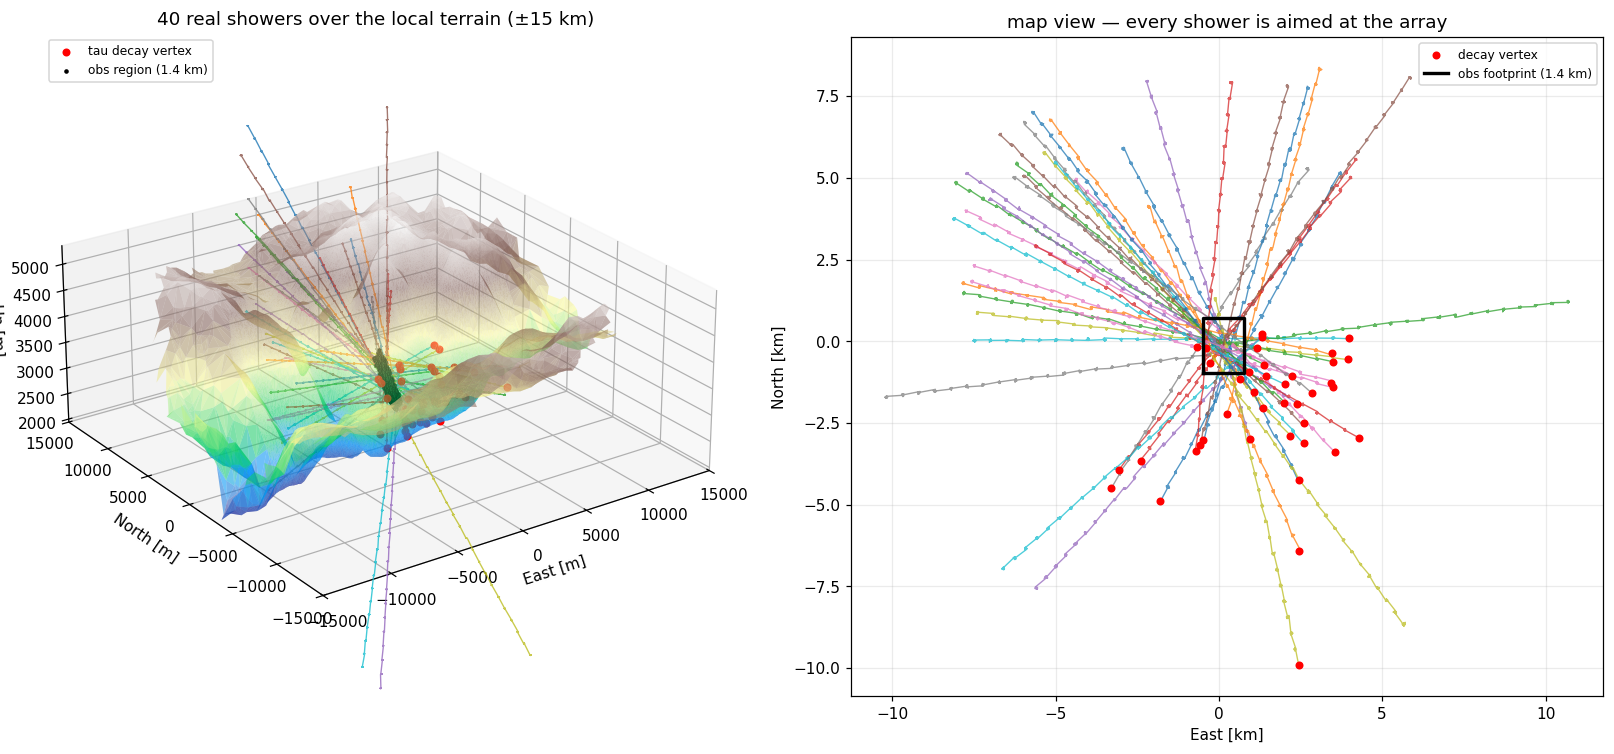

In [13]:
# ── Showers overlaid on the mountain ─────────────────────────────────────────
# Positioning goes through the pipeline's own `place_clouds_enu` (what Step 1 uses).
# This notebook used to carry its own copy (`shower_points`, the C8 e1/e2 basis),
# which went stale when the frame was corrected — that is why its plots looked
# healthy while real trigger counts were ~2%. One implementation now.
#
# `place_clouds_enu` takes a NATIVE cloud [x, y, layer, energy, time] whose cols 0/1
# are horizontal (East, North) offsets already carrying the longitudinal development,
# so an illustrative rod is col0 = layer*dx*d_E + lateral, col1 = layer*dx*d_N + lateral.
from modules_v6.fnn_surrogate_ne import place_clouds_enu, cloud_to_enu

NLAY, PER, SIG = N_PLANES, 30, 20.0          # planes, points/plane, lateral sigma [m]
_lay = np.repeat(np.arange(NLAY), PER).astype(np.float32)
_rng = np.random.default_rng(0)

def rod(i, rng=_rng):
    """Shower i as an (P,3) ENU cloud, placed by the pipeline's `place_clouds_enu`
    so the rod lands wherever Step 1 would put it — no parallel algebra."""
    p = np.array([tE_e[i], tN_n[i], tU_u[i]], dtype=np.float32)
    d = (tdir[:, i] / np.linalg.norm(tdir[:, i])).astype(np.float32)
    s = _lay * LAYER_EAST_DX
    cloud = np.zeros((1, _lay.size, 5), np.float32)
    cloud[0, :, 0] = s * d[0] + rng.normal(0, SIG, _lay.size)   # East  offset
    cloud[0, :, 1] = s * d[1] + rng.normal(0, SIG, _lay.size)   # North offset
    cloud[0, :, 2] = _lay
    cloud[0, :, 3] = 1.0                                        # energy > 0 = live
    cloud[0, :, 4] = 1.0
    placed = place_clouds_enu(torch.from_numpy(cloud),
                              torch.from_numpy(p).view(1, 3),
                              torch.from_numpy(d).view(1, 3),
                              east_entry=EAST_ENTRY, layer_east_dx=LAYER_EAST_DX)
    return cloud_to_enu(placed[0])                              # (M,3) [East,North,Up]

def shower_points(*_a, **_k):
    """Deprecated — positioning lives in place_clouds_enu; use rod(i)."""
    raise NotImplementedError(
        "shower_points was a duplicate of the pipeline transform and went stale. "
        "Use rod(i), which calls place_clouds_enu.")

# Sanity: the rod must lie ON the tau axis. Exercises `place_clouds_enu` itself, so
# it fails loudly if the pipeline transform ever drifts from what this notebook draws.
_i = int(np.where(inband)[0][0]); _p = np.array([tE_e[_i], tN_n[_i], tU_u[_i]])
_d = tdir[:, _i] / np.linalg.norm(tdir[:, _i])
_ax = rod(_i, rng=np.random.default_rng(0))
_dev = np.linalg.norm(_ax - _p - ((_ax - _p) @ _d)[:, None] * _d[None, :], axis=1)
print(f"axis check: start err {np.linalg.norm(_ax[0]-_p):.0f} m "
      f"(lateral sigma={SIG:g}), max off-axis {_dev.max():.0f} m, "
      f"span {((_ax-_p) @ _d).max()/1e3:.1f} km of {LAYER_EAST_DX*(NLAY-1)/1e3:.1f} km")

sel  = np.where(inband & (np.hypot(tE_e, tN_n) < LOC_R))[0]
pick = _rng.choice(sel, size=min(40, sel.size), replace=False)
print(f"in-band decays within {LOC_R/1e3:.0f} km: {sel.size}  (drawing {pick.size})")

fig = plt.figure(figsize=(15, 6.8))
ax0 = fig.add_subplot(1, 2, 1, projection="3d")
add_terrain(ax0, alpha=0.55)
for i in pick:
    P = rod(i); ax0.plot(P[:, 0], P[:, 1], P[:, 2], lw=0.9, alpha=0.8)
ax0.scatter(tE_e[pick], tN_n[pick], tU_u[pick], c="red", s=18,
            depthshade=False, label="tau decay vertex")
ax0.scatter(mE, mN, mU, c="k", s=4, depthshade=False, label="obs region (1.4 km)")
ax0.set(xlabel="East [m]", ylabel="North [m]", zlabel="Up [m]")
ax0.set_box_aspect((1, 1, 0.42))          # mild Up exaggeration; terrain is 30 km wide
ax0.set_title(f"{pick.size} real showers over the local terrain (±{LOC_R/1e3:.0f} km)")
ax0.view_init(elev=24, azim=-125); ax0.legend(loc="upper left", fontsize=8)

ax1 = fig.add_subplot(1, 2, 2)
for i in pick:
    P = rod(i); ax1.plot(P[:, 0] / 1e3, P[:, 1] / 1e3, lw=0.9, alpha=0.75)
ax1.scatter(tE_e[pick] / 1e3, tN_n[pick] / 1e3, c="red", s=18, zorder=5, label="decay vertex")
ax1.plot(np.array([mE.min(), mE.max(), mE.max(), mE.min(), mE.min()]) / 1e3,
         np.array([mN.min(), mN.min(), mN.max(), mN.max(), mN.min()]) / 1e3,
         "k-", lw=2.2, zorder=6, label="obs footprint (1.4 km)")
ax1.set(xlabel="East [km]", ylabel="North [km]", aspect="equal",
        title="map view — every shower is aimed at the array")
ax1.legend(fontsize=8)
fig.tight_layout(pad=1.5); plt.show()

### 9b - Where along its axis does each shower meet the array?

`tau_wholesky.jl` keeps only taus whose forward ray still crosses the observation
mesh, so **direction alone carries little information - every shower is aimed at the
array** (the map view above). What actually varies is the *distance* from the decay
vertex to the array, and therefore how far the shower has developed on arrival.

That distance is set by the decay **position**, which is not part of the surrogate's
5-dim primary `[dir_x, dir_y, dir_z, log_e_norm, pdg]`. Two taus with the same
direction and energy but different decay distance give different detector responses
from *identical network input* - the aliasing the histogram below quantifies.

decay -> array along the axis [km]: p5=0.69  p50=2.99  p95=8.12
layer index on arrival: p5=1.4  p50=6.0  p95=16.2   (model spans 0..23)
arrives beyond the modelled 11.5 km shower: 1.4%
in-band showers whose 11.5 km axis crosses the footprint: 595009/602278 (98.8%)


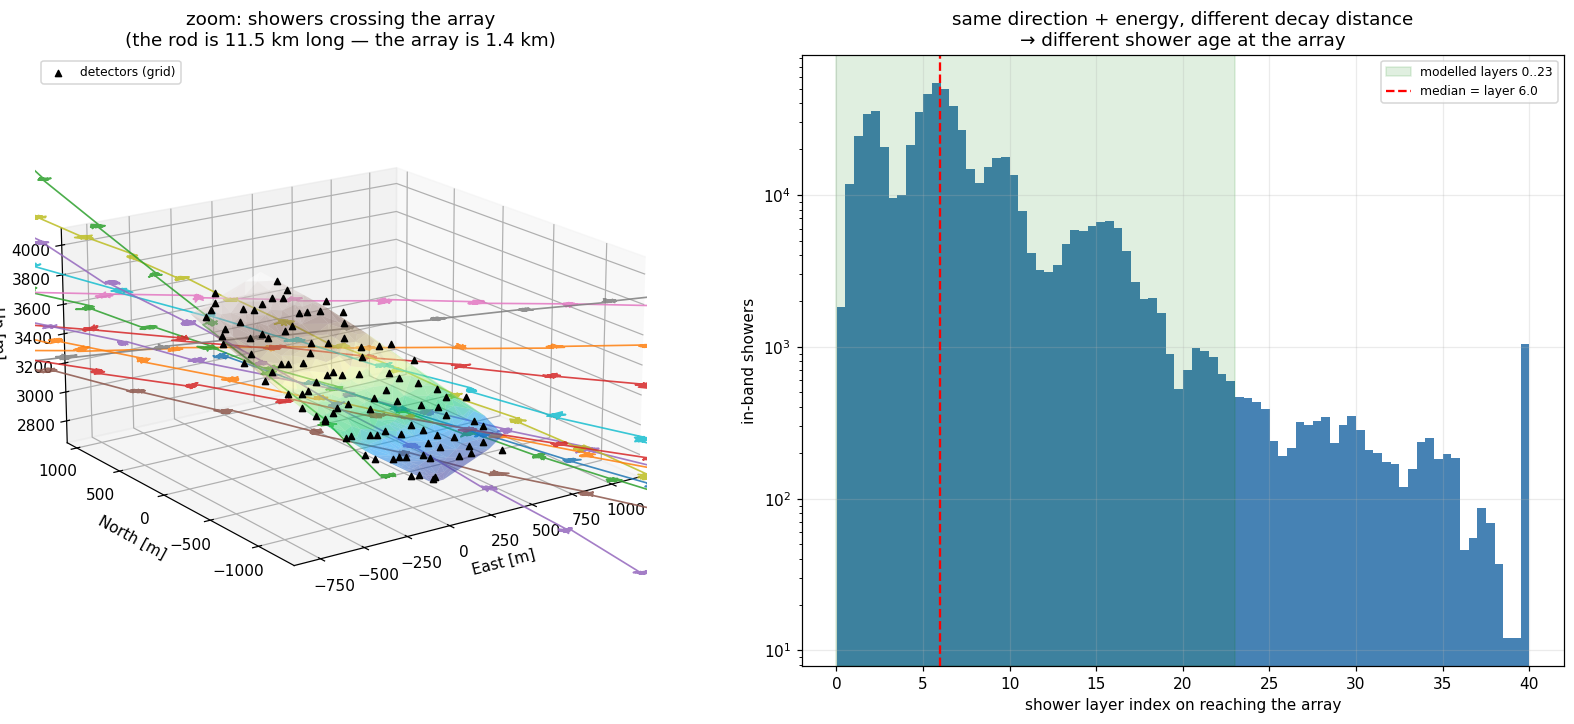

In [14]:
# ── How far along its axis is each shower when it reaches the array? ─────────
# The corpus is CUT so every surviving tau's forward ray crosses the observation
# mesh (tau_wholesky.jl step 5), so direction alone says little — what varies is
# the DISTANCE from the decay vertex to the array, i.e. how developed the shower
# is on arrival. That distance is set by the decay POSITION, which is not part of
# the surrogate's 5-dim primary [dir_x, dir_y, dir_z, log_e_norm, pdg].
ib   = np.where(inband)[0]
p_ib = np.stack([tE_e[ib], tN_n[ib], tU_u[ib]], axis=1)
d_ib = (tdir[:, ib] / np.linalg.norm(tdir[:, ib], axis=0)).T
c_arr = np.array([mE.mean(), mN.mean(), mU.mean()])            # array centre
t_path = ((c_arr[None, :] - p_ib) * d_ib).sum(1)               # along-axis distance [m]
fwd    = t_path > 0
lay_at = t_path[fwd] / LAYER_EAST_DX                           # in layer-index units
L_max  = (N_PLANES - 1) * LAYER_EAST_DX
print(f"decay -> array along the axis [km]: "
      f"p5={np.percentile(t_path[fwd],5)/1e3:.2f}  p50={np.percentile(t_path[fwd],50)/1e3:.2f}  "
      f"p95={np.percentile(t_path[fwd],95)/1e3:.2f}")
print(f"layer index on arrival: p5={np.percentile(lay_at,5):.1f}  p50={np.percentile(lay_at,50):.1f}  "
      f"p95={np.percentile(lay_at,95):.1f}   (model spans 0..{N_PLANES-1})")
print(f"arrives beyond the modelled {L_max/1e3:.1f} km shower: {100*(t_path[fwd]>L_max).mean():.1f}%")

# showers whose axis actually crosses the footprint box
def axis_crosses(i, n=400):
    p = np.array([tE_e[i], tN_n[i], tU_u[i]]); d = tdir[:, i] / np.linalg.norm(tdir[:, i])
    q = p[None, :] + np.linspace(0, L_max, n)[:, None] * d[None, :]
    return ((q[:,0] >= mE.min()) & (q[:,0] <= mE.max()) &
            (q[:,1] >= mN.min()) & (q[:,1] <= mN.max())).any()
hit = ib[[axis_crosses(i) for i in ib]]
print(f"in-band showers whose {L_max/1e3:.1f} km axis crosses the footprint: "
      f"{hit.size}/{ib.size} ({100*hit.size/ib.size:.1f}%)")

fig = plt.figure(figsize=(15, 6.8))
ax0 = fig.add_subplot(1, 2, 1, projection="3d")
ax0.plot_trisurf(mE, mN, mU, cmap="terrain", alpha=0.5, linewidth=0)
E_g, N_g = layouts["grid"]
ax0.scatter(E_g, N_g, det_up(N_g, E_g), c="k", s=16, marker="^",
            depthshade=False, label="detectors (grid)")
for i in hit[:14]:
    P = rod(i); ax0.plot(P[:, 0], P[:, 1], P[:, 2], lw=1.1, alpha=0.85)
ax0.set(xlabel="East [m]", ylabel="North [m]", zlabel="Up [m]")
ax0.set_xlim(mE.min() - 400, mE.max() + 400); ax0.set_ylim(mN.min() - 400, mN.max() + 400)
ax0.set_zlim(mU.min() - 100, mU.max() + 400); ax0.set_box_aspect((1, 1, 0.55))
ax0.set_title("zoom: showers crossing the array\n(the rod is 11.5 km long — the array is 1.4 km)")
ax0.view_init(elev=18, azim=-125); ax0.legend(loc="upper left", fontsize=8)

ax1 = fig.add_subplot(1, 2, 2)
ax1.hist(np.clip(lay_at, 0, 40), bins=80, color="steelblue")
ax1.axvspan(0, N_PLANES - 1, color="green", alpha=0.12, label=f"modelled layers 0..{N_PLANES-1}")
ax1.axvline(np.median(lay_at), color="r", ls="--",
            label=f"median = layer {np.median(lay_at):.1f}")
ax1.set(xlabel="shower layer index on reaching the array", ylabel="in-band showers", yscale="log",
        title="same direction + energy, different decay distance\n→ different shower age at the array")
ax1.legend(fontsize=8)
fig.tight_layout(pad=1.5); plt.show()